# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning



_Fill in your group number **from Brightspace**, names, and student numbers._
    
| Group          | 71      |
|----------------|---------|
| Bente van Geen | XXXXXXX |
| Femke Knibbe   | XXXXXXX |
| Lauren But     | XXXXXXX |
| Henno Kruis    | 5988063 |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [2]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        actions = agent.get_valid_actions(maze)

        # random.choice assumes at least one element in the list
        if not actions:
            return None

        return random.choice(actions)

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        actions = agent.get_valid_actions(maze)
        state = agent.get_state(maze)

        if not actions:
            return None


        if random.random() < eps:
            return random.choice(actions)


        q_values = [self.q_table.get_q(state, a) for a in actions]
        best_action = actions[np.argmax(q_values)]
        return best_action

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        actions = agent.get_valid_actions(maze)
        state = agent.get_state(maze)

        if not actions:
            return None

        q_values = [self.q_table.get_q(state, a) for a in actions]

        if temperature <= 0:
            return actions[np.argmax(q_values)]

        exp_values = [np.exp(q / temperature) for q in q_values]
        probs = [v / sum(exp_values) for v in exp_values]

        return np.random.choice(actions, p=probs)  #np.random better for lists


Discussion
### *Random*

The random exploration strategy selects an action uniformly at random from the set of all valid actions available. Every action has equal probability of being chosen.

This strategy is useful in the early stages of learning because it guarantees full exploration of the maze. However, it does not take into account any learned information. This makes it that 'bad' actions will still be chosen over time.

### *ε-greedy*

The ε-greedy strategy balances exploration and exploitation by introducing a probability ε. A random number between 0 and 1:

If the number is less than ε, a random action is selected (exploration) otherwise the action with the highest Q-value is selected (exploitation)

This approach allows the agent to gradually shift from exploration to exploitation.

One drawback during exploration, actions are still chosen uniformly at random, making it such that poor actions are explored as often as good actions.

### *Boltzmann (Softmax)*

The Boltzmann exploration strategy assigns probabilities to actions based on their Q-values using a softmax function. Actions with higher Q-values are more likely to be selected, but lower-valued actions still have a chance depending on the temperature parameter T.

With high temperature the probabilities are more uniform which means more exploration.
With low temperature probabilities concentrate on the best action which means more exploitation

Hyper-parameter choices
ε (epsilon): Initially set between 0.1 and 0.3 to ensure sufficient exploration. Optionally decayed over time to reduce randomness as learning progresses.
Temperature (T): Started at a higher value (T ~ 1.0) and gradually decreased.

These values were chosen to ensure that the agent explores enough early on while still allowing convergence later.

#### Question 2

In [45]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

### Agent cycle

In [47]:
episode_lengths = []
episode_rewards = []
n_episodes = 300
max_steps = 1000

for episode in tqdm(range(n_episodes)):

    agent.reset()
    done = False
    episode_reward = 0

    while not done and agent.nr_of_actions_since_reset < max_steps:

        state = agent.get_state(maze)
        action = exploration_strategy.boltzmann(agent, maze, temperature=1.0)
        next_state, reward, done = agent.step(action, maze)
        # learner.learn(state, action, reward, next_state)
        episode_reward += reward

    episode_lengths.append(agent.nr_of_actions_since_reset)
    episode_rewards.append(episode_reward)

print(f"Episodes completed: {len(episode_lengths)}, total steps: {sum(episode_lengths)}")
# print(f"Episode rewards: {episode_rewards}")

100%|██████████| 300/300 [00:02<00:00, 120.56it/s]

Episodes completed: 300, total steps: 232674


The cycle runs for a fixed number of episodes n_episodes. Each episode represents one full attempt by the agent to find the goal.
At the start of each episode the agent is reset to its initial position. This is necessary to ensure each episode is an independent trial.
Within each episode, the agent repeatedly selects an action using the chosen exploration strategy, and observes the resulting next state and reward.
The episode ends when one of two conditions is met: the agent reaches the goal, or it exceeds *max_steps* steps. The *max_steps* limit is necessary because, especially early in training when the Q-table is uninformed, the agent may traverse without ever finding the goal. Without this limit a single episode could run forever, making the overall training infeasible.
At the end of each episode the total reward and number of steps are recorded. These are used to track whether the agent is improving over time. A well-learning agent should show increasing rewards and decreasing episode lengths as training progresses, however since we have not implemented the learner methods this should not show up.

#### Question 3

In [56]:
def run_agent(maze, agent, exploration_strategy, n_episodes, max_steps, max_total_steps):

    ep_lengths = []
    ep_rewards = []
    total_steps = 0

    for episode in tqdm(range(n_episodes)):
        if total_steps >= max_total_steps:
            break

        agent.reset()
        done = False
        episode_reward = 0

        while not done and agent.nr_of_actions_since_reset < max_steps:
            if total_steps >= max_total_steps:
                break

            state = agent.get_state(maze)
            action = exploration_strategy.boltzmann(agent, maze, temperature=1.0)
            next_state, reward, done = agent.step(action, maze)
            # learner.learn(state, action, reward, next_state)
            episode_reward += reward
            total_steps += 1

        ep_lengths.append(agent.nr_of_actions_since_reset)
        ep_rewards.append(episode_reward)
    return ep_lengths, ep_rewards

episode_lengths, episode_rewards = run_agent(maze, agent, exploration_strategy, n_episodes=300, max_steps=1000, max_total_steps=30000)

print(f"Episodes completed: {len(episode_lengths)}, total steps: {sum(episode_lengths)}")
print(f"Episode rewards: {episode_rewards}")

 12%|█▏        | 37/300 [00:00<00:02, 103.08it/s]

Episodes completed: 37, total steps: 30000
Episode rewards: [0, 0, 0, 0, 0, 0, 10, 10, 0, 0, 10, 10, 0, 0, 0, 0, 0, 0, 0, 0, 10, 10, 0, 0, 10, 0, 10, 10, 0, 0, 0, 10, 0, 0, 0, 0, 0]



The stopping criterion was implemented by maintaining a ***total_steps*** counter that increments by 1 after every action taken across all episodes. The criterion is checked in two places: before starting a new episode (to avoid beginning an episode that cannot complete), and inside the step loop (to stop mid-episode the moment the ***max_total_steps*** is reached). It can also be observed that in theory the total amount of steps across all episodes would be 300.000 (300 episodes with 1000 steps), thus the stopping criterion is the 30000 steps allowed to take

#### Question 4

 29%|██▊       | 86/300 [00:00<00:01, 132.03it/s]


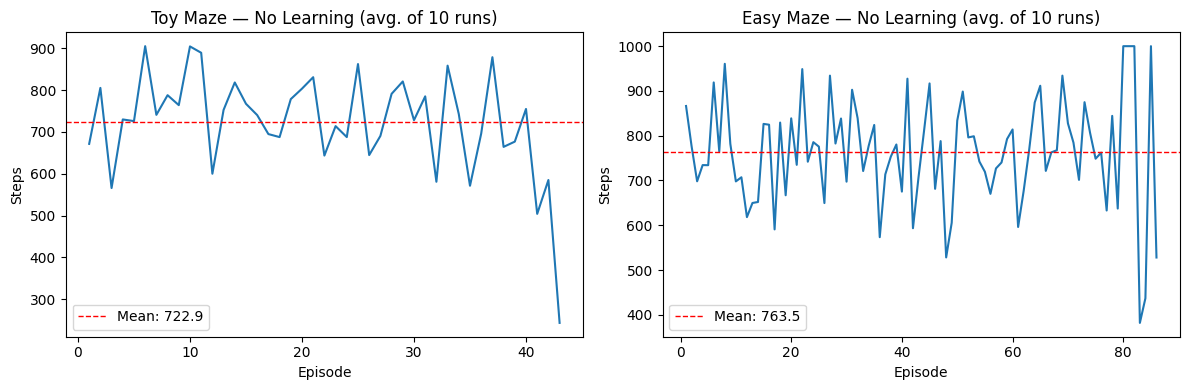

In [63]:
def average_runs(maze_path, reward_x, reward_y, start_x, start_y,
                 n_runs=10, n_episodes=300, max_steps=1000, max_total_steps=30000):
    all_lengths = []

    for _ in range(n_runs):
        maze = Maze(maze_path)
        maze.set_reward(x=reward_x, y=reward_y, reward=10)
        maze.set_terminal(x=reward_x, y=reward_y)
        agent = Agent(start_x=start_x, start_y=start_y)
        states = maze.get_all_states()
        actions = [Action(a) for a in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)

        lengths, _ = run_agent(maze, agent, exploration_strategy,
                            n_episodes, max_steps, max_total_steps)
        all_lengths.append(lengths)

    #Pad all the shorter runs such that it can be visually represented in the plots
    max_len = max(len(r) for r in all_lengths)
    padded = np.full((n_runs, max_len), np.nan)
    for i, r in enumerate(all_lengths):
        padded[i, :len(r)] = r

    avg = np.nanmean(padded, axis=0)
    return avg


avg_toy  = average_runs("./../data/toy_maze.txt",  reward_x=9, reward_y=9, start_x=0, start_y=0)
avg_easy = average_runs("./../data/easy_maze.txt", reward_x=9, reward_y=9, start_x=0, start_y=0,
                        max_total_steps=60000)  # larger maze needs more steps


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, avg, title in zip(axes, [avg_toy, avg_easy], ["Toy Maze", "Easy Maze"]):
    ax.plot(range(1, len(avg) + 1), avg, linewidth=1.5)
    ax.axhline(np.nanmean(avg), color='red', linestyle='--', linewidth=1, label=f'Mean: {np.nanmean(avg):.1f}')
    ax.set_xlabel("Episode")
    ax.set_ylabel("Steps")
    ax.set_title(f"{title} — No Learning (avg. of 10 runs)")
    ax.legend()

plt.tight_layout()
plt.show()

Runs stop at max_total_steps, not at a fixed episode count, so different runs may complete a different number of episodes. Shorter runs are padded with NaN and np.nanmean is used so the average is only computed over runs that actually reached that episode, keeping the plot meaningful rather than dragging the average down artificially.
### plots:
The average steps per episode should show no downward trend. The line stays flat or noisy around the mean for both mazes. This is expected because the Q-table is never updated, so the agent has no memory. Every episode starts with the same all-zero Q-table, making Boltzmann exploration effectively random every time. The easy maze will show higher and more variable step counts than the toy maze simply because it is larger (25×15 vs 10×10) and the goal is harder to stumble upon by chance.



#### Question 5

In [64]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action, next_state: State, reward: int, done: bool) -> None:
        if done:
            return

        learning_rate = self.params["lr"]
        discount_factor = self.params["gamma"]

        best_q = max(self.q_table.get_q(next_state, action) for action in possible_actions)

        current_q = self.q_table.get_q(state, action)
        new_q = current_q + learning_rate * (reward + (discount_factor * best_q) - current_q)
        self.q_table.set_q(state, action, new_q)

In [65]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action, reward: float, done: bool) -> None:
        if done:
            return

        learning_rate = self.params["lr"]
        discount_factor = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)
        next_q = self.q_table.get_q(next_state, next_action)
        new_q = current_q + learning_rate * (reward + (discount_factor * next_q) - current_q)
        self.q_table.set_q(state, action, new_q)

#### Q-Learning


Q-Learning updates the Q-value of the current state-action pair using the Bellman equation:
Q(s,a) ← Q(s,a) + α(r + γ·max Q(s',a') − Q(s,a)).
The key term is max Q(s', a_max), the update always assumes the best possible action will be chosen from the next state. The result is that Q-Learning learns the optimal policy directly. The trade-off is that it can be less stable early in training.

#### SARSA
SARSA updates using:
Q(s,a) ← Q(s,a) + α(r + γ·Q(s',a') − Q(s,a)).
Here a' is the action the agent actually takes in the next state. This means if the agent uses ε-greedy, SARSA accounts for the fact that it will sometimes take random actions.





#### Question 6



_Put your code blocks above (if any) and write your answer here._

#### Question 7



_Write your answer here._

### 2.2 Optimization
#### Question 8



_Put your code blocks above (if any) and write your answer here._

#### Question 9



_Write your answer here._

#### Question 10



_Put your code blocks above (if any) and write your answer here._

#### Question 11



_Put your code blocks above (if any) and write your answer here._

#### Question 12



_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13



_Put your code blocks above (if any) and write your answer here._

#### Question 14



_Put your code blocks above (if any) and write your answer here._

#### Question 15



_Put your code blocks above (if any) and write your answer here._

#### Question 16



_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17



_Write your answer here._

#### Question 18



_Write your answer here._

#### Question 19



_Write your answer here._

### 3.2 Pen and Paper
#### Question 20



_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21



_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22



_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23




|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References



**If you made use of any non-course resources, cite them below.**

### Use of AI
In question 4 AI was used as assinstance to make the graphs more informative